# Deskripsi Dataset

Dataset ini merupakan data transaksi penjualan e-commerce berbasis di UK selama 1 tahun.
Total data: ±500.000 baris dan 8 kolom.

| No | Nama Kolom        | Deskripsi                                                                                                                              |
| -- | ----------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| 1  | **TransactionNo** | Nomor unik 6 digit untuk setiap transaksi. Jika diawali huruf **“C”**, berarti transaksi tersebut merupakan pembatalan (cancellation). |
| 2  | **Date**          | Tanggal saat transaksi dibuat.                                                                                                         |
| 3  | **ProductNo**     | Kode unik 5–6 digit untuk mengidentifikasi produk tertentu.                                                                            |
| 4  | **ProductName**       | Nama produk atau item yang dibeli pelanggan.                                                                                           |
| 5  | **Price**         | Harga per unit produk dalam Poundsterling (£).                                                                                         |
| 6  | **Quantity**      | Jumlah produk dalam setiap transaksi. Nilai negatif menunjukkan transaksi pembatalan atau refund.                                      |
| 7  | **CustomerNo**    | Nomor unik yang mengidentifikasi setiap pelanggan.                                                                                     |
| 8  | **Country**       | Negara tempat pelanggan berasal.                                                                                                       |


In [2]:
!pip install --upgrade kagglehub[pandas-datasets]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


# Library yang digunakan

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import kstest
import math

# Load Dataset Sales Transaction dari Kaggle

In [5]:
# Login
kagglehub.login()

# Load dataset

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "gabrielramos87/an-online-shop-business",
    "Sales Transaction v.4a.csv"
)

/tmp/ipykernel_367/1269683284.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'an-online-shop-business' dataset.


# Data Exploration

## Menampilkan data

**`df.head()`** menampilkan beberapa baris teratas atau pertama dari dataset

In [6]:
df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


## Info data

**`df.info()`** memberikan ringkasan struktur DataFrame, termasuk jumlah baris, kolom, tipe data, nilai non-null, dan penggunaan memori, membantu memahami data sebelum analisis.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


Pada dataset ini terdapat 536.350 data dengan 8 kolom. Seluruh kolom non-null yang berarti tidak ada missing value atau data kosong. Memiliki 1 kolom dengan tipe data numerik atau int, 2 kolom dengan tipe data float atau kontinu, dan 5 kolom dengan tipe data kategorikal atau object.

## Menampilkan ringkasan statistik

**`Statistik deskriptif`** untuk melihat ringkasan statistik dari data numerik

In [8]:
df[['Price', 'Quantity']].describe()

,Price,Quantity
count,536350.000000,536350.000000
mean,12.662182,9.919347
std,8.490450,216.662300
min,5.130000,-80995.000000
25%,10.990000,1.000000
50%,11.940000,3.000000
75%,14.090000,10.000000
max,660.620000,80995.000000


Dari hasil ringkasan statistik pada data ini :
Rata-rata harga produk adalah £12,66

- Harga termurah sekitar £5,13
- Harga termahal mencapai £660,62
- Sebagian besar harga produk berada di kisaran £10 – £14
- 50% transaksi memiliki harga di bawah £11,94
- Toko ini mayoritas menjual produk dengan harga terjangkau
- Rata-rata jumlah barang per transaksi adalah 9–10 produk
- Mayoritas pelanggan belanja dalam jumlah kecil
- Nilai negatif menunjukkan transaksi pembatalan (cancel/refund)

## Memeriksa data kosong

In [9]:
pd.isnull(df).sum()

,0
TransactionNo,0
Date,0
ProductNo,0
ProductName,0
Price,0
Quantity,0
CustomerNo,55
Country,0


In [10]:
missing_percent = df.isnull().mean() * 100
missing_percent

,0
TransactionNo,0.000000
Date,0.000000
ProductNo,0.000000
ProductName,0.000000
Price,0.000000
Quantity,0.000000
CustomerNo,0.010254
Country,0.000000


Pada data ini terdapat data yang kosong yaitu pada kolom `CustomerNo` sebanyak 55 dari 536.350 data atau sebesar 1.03%

## Memeriksa duplikasi data

In [11]:
df.duplicated().sum()

np.int64(5200)

Terdapat duplikasi data sebanyak 5200

### Menampilkan duplikasi data

In [12]:
df[df.duplicated(subset=['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity', 'CustomerNo', 'Country'], keep=False)].sort_values(by=['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity', 'CustomerNo', 'Country'])

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
533729,536409,12/1/2018,21866,Union Jack Flag Luggage Tag,11.53,1,17908.0,United Kingdom
533752,536409,12/1/2018,21866,Union Jack Flag Luggage Tag,11.53,1,17908.0,United Kingdom
533720,536409,12/1/2018,22111,Scottie Dog Hot Water Bottle,15.32,1,17908.0,United Kingdom
533771,536409,12/1/2018,22111,Scottie Dog Hot Water Bottle,15.32,1,17908.0,United Kingdom
533724,536409,12/1/2018,22866,Hand Warmer Scotty Dog Design,12.40,1,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
102612,C574510,11/4/2019,22360,Glass Jar English Confectionery,13.27,-1,15110.0,United Kingdom
80075,C575940,11/13/2019,23309,Set Of 60 I Love London Cake Cases,10.81,-24,17838.0,United Kingdom
80076,C575940,11/13/2019,23309,Set Of 60 I Love London Cake Cases,10.81,-24,17838.0,United Kingdom
12213,C580764,12/6/2019,22667,Recipe Box Retrospot,6.19,-12,14562.0,United Kingdom


## Distribusi Data

Analisis distribusi dan memeriksa normalisasi pada data
- Dilakukan pemeriksaan data distribusi yaitu pola sebaran data untuk melihat bagaimana nilai data tersebar.
- Pemriksaan persebaran data menggunakan Uji Kolmogorov–Smirnov karena jumlah data > 5000


In [13]:
import numpy as np
from scipy.stats import kstest

numeric_cols = df.select_dtypes(include=np.number).columns

# Hapus CustomerNo dari pengujian
numeric_cols = numeric_cols.drop('CustomerNo')

for col in numeric_cols:

    data_z = (df[col] - df[col].mean()) / df[col].std()
    data_z = data_z.dropna()

    stat, p = kstest(data_z, 'norm')

    print(f"Kolom: {col}")
    print(f"  Statistik uji : {stat:.4f}")
    print(f"  p-value       : {p:.6f}")

    if p > 0.05:
        print("  ➜ Data berdistribusi normal\n")
    else:
        print("  ➜ Data tidak berdistribusi normal\n")

Kolom: Price
  Statistik uji : 0.2467
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: Quantity
  Statistik uji : 0.4712
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal



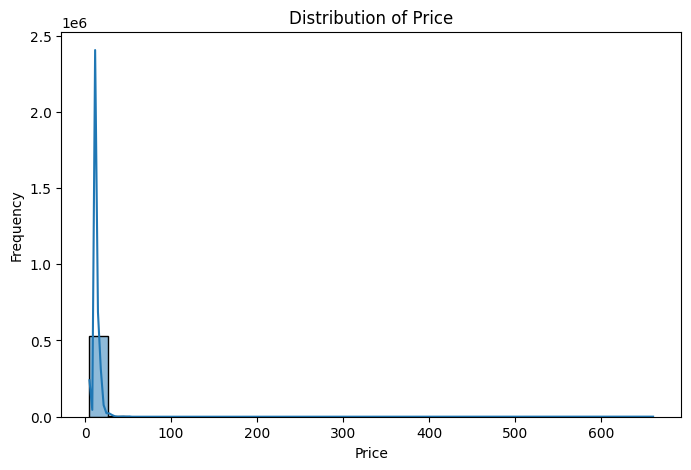

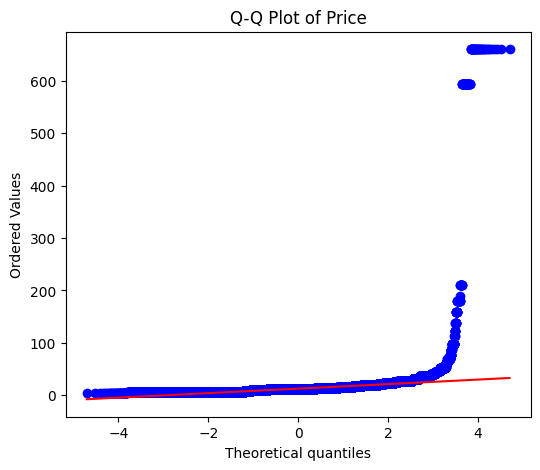

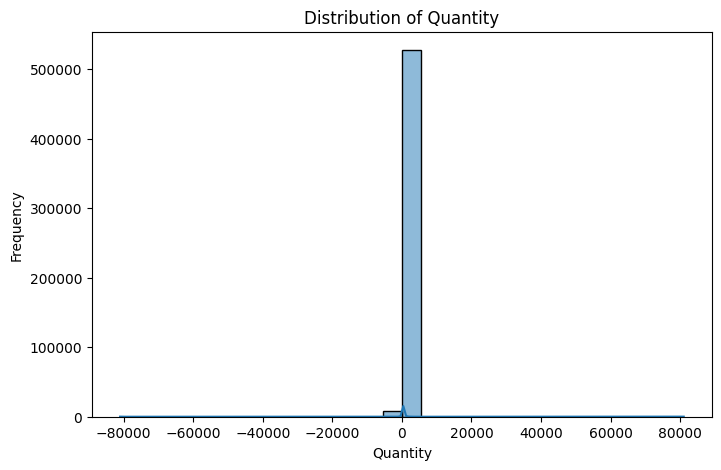

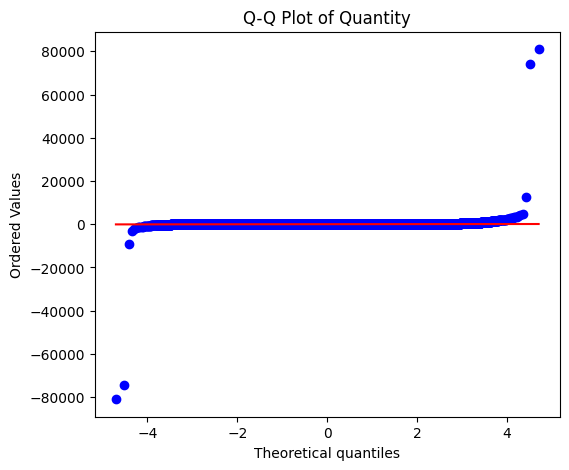

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot

# Ambil semua kolom numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Hapus CustomerNo
numeric_cols = numeric_cols.drop('CustomerNo')

# Loop untuk setiap kolom numerik (tanpa CustomerNo)
for col in numeric_cols:

    data = df[col].dropna()

    # HISTOGRAM
    plt.figure(figsize=(8,5))
    sns.histplot(data, bins=30, kde=True, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

    # Q-Q PLOT
    plt.figure(figsize=(6,5))
    probplot(data, dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {col}')
    plt.show()

Hasil uji normalitas menunjukkan Price dan Quantity tidak berdistribusi normal, yang merupakan karakteristik umum pada data transaksi retail karena adanya variasi pembelian

## Normalisasi Data

In [15]:
df_norm = df.copy()

In [16]:

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df_norm[['Price_scaled','Quantity_scaled']] = scaler.fit_transform(
    df_norm[['Price','Quantity']]
)

df_norm[['Price','Price_scaled','Quantity','Quantity_scaled']].head()

,Price,Price_scaled,Quantity,Quantity_scaled
0,21.47,3.074194,12,1.000000
1,10.65,-0.416129,36,3.666667
2,11.53,-0.132258,12,1.000000
3,10.65,-0.416129,12,1.000000
4,11.94,0.000000,6,0.333333


Memeriksa hasil normalisasi data

In [17]:
import numpy as np
from scipy.stats import kstest

numeric_cols = df_norm.select_dtypes(include=np.number).columns

# Hapus CustomerNo dari pengujian
numeric_cols = numeric_cols.drop('CustomerNo')

for col in numeric_cols:

    data_z = (df_norm[col] - df_norm[col].mean()) / df_norm[col].std()
    data_z = data_z.dropna()

    stat, p = kstest(data_z, 'norm')

    print(f"Kolom: {col}")
    print(f"  Statistik uji : {stat:.4f}")
    print(f"  p-value       : {p:.6f}")

    if p > 0.05:
        print("  ➜ Data berdistribusi normal\n")
    else:
        print("  ➜ Data tidak berdistribusi normal\n")

Kolom: Price
  Statistik uji : 0.2467
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: Quantity
  Statistik uji : 0.4712
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: Price_scaled
  Statistik uji : 0.2467
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: Quantity_scaled
  Statistik uji : 0.4712
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal



# Data Cleaning

## Memeriksa konsistensi data kategorikal

In [18]:
# 1. Atur agar kolom tidak dipotong (max width di-set ke None)
pd.set_option('display.max_colwidth', None)

list_info = []

for col in df_norm.columns:
    list_info.append([
        col,
        df_norm[col].dtype,
        df_norm[col].nunique(),
        list(df_norm[col].unique())
    ])

df_info = pd.DataFrame(columns=['column', 'dtype', 'n_unique', 'unique_values'], data=list_info)

# 2. Tampilkan dataframe
display(df_info)

,column,dtype,n_unique,unique_values
0,TransactionNo,object,23204,"[581482, 581475, 581476, 581477, 581478, 581479, 581480, 581481, 581483, 581485, 581486, 581487, 581488, 581489, 581491, 581492, 581493, 581494, 581495, 581496, 581497, 581498, 581500, 581501, 581502, 581514, 581516, 581538, 581566, 581567, 581570, 581571, 581572, 581574, 581578, 581579, 581580, 581581, 581582, 581583, 581584, 581585, 581586, 581587, C581484, C581490, C581568, C581569, 581214, 581215, 581216, 581217, 581218, 581219, 581220, 581221, 581222, 581223, 581224, 581225, 581227, 581230, 581231, 581232, 581233, 581236, 581237, 581238, 581241, 581246, 581251, 581252, 581253, 581256, 581266, 581279, 581281, 581285, 581291, 581310, 581324, 581325, 581327, 581333, 581334, 581335, 581336, 581338, 581345, 581352, 581356, 581357, 581358, 581361, 581375, 581376, 581377, 581378, 581379, 581380, ...]"
1,Date,object,305,"[12/9/2019, 12/8/2019, 12/7/2019, 12/6/2019, 12/5/2019, 12/4/2019, 12/2/2019, 12/1/2019, 11/30/2019, 11/29/2019, 11/28/2019, 11/27/2019, 11/25/2019, 11/24/2019, 11/23/2019, 11/22/2019, 11/21/2019, 11/20/2019, 11/18/2019, 11/17/2019, 11/16/2019, 11/15/2019, 11/14/2019, 11/13/2019, 11/11/2019, 11/10/2019, 11/9/2019, 11/8/2019, 11/7/2019, 11/6/2019, 11/4/2019, 11/3/2019, 11/2/2019, 11/1/2019, 10/31/2019, 10/30/2019, 10/28/2019, 10/27/2019, 10/26/2019, 10/25/2019, 10/24/2019, 10/23/2019, 10/21/2019, 10/20/2019, 10/19/2019, 10/18/2019, 10/17/2019, 10/16/2019, 10/14/2019, 10/13/2019, 10/12/2019, 10/11/2019, 10/10/2019, 10/9/2019, 10/7/2019, 10/6/2019, 10/5/2019, 10/4/2019, 10/3/2019, 10/2/2019, 9/30/2019, 9/29/2019, 9/28/2019, 9/27/2019, 9/26/2019, 9/25/2019, 9/23/2019, 9/22/2019, 9/21/2019, 9/20/2019, 9/19/2019, 9/18/2019, 9/16/2019, 9/15/2019, 9/14/2019, 9/13/2019, 9/12/2019, 9/11/2019, 9/9/2019, 9/8/2019, 9/7/2019, 9/6/2019, 9/5/2019, 9/4/2019, 9/2/2019, 9/1/2019, 8/31/2019, 8/30/2019, 8/28/2019, 8/26/2019, 8/25/2019, 8/24/2019, 8/23/2019, 8/22/2019, 8/21/2019, 8/19/2019, 8/18/2019, 8/17/2019, 8/16/2019, 8/15/2019, ...]"
2,ProductNo,object,3768,"[22485, 22596, 23235, 23272, 23239, 21705, 22118, 22119, 22217, 22216, 22380, 22442, 22664, 22721, 22723, 22785, 22955, 23141, 22956, 22581, 23198, 23197, 23184, 23168, 23167, 23166, 23165, 23004, 23002, 23000, 22998, 22994, 22835, 22730, 22728, 22727, 22726, 22720, 22693, 22670, 22667, 22666, 22631, 22628, 22467, 22197, 22114, 22112, 21908, 21874, 21872, 21871, 21533, 21481, 21479, 21248, 21216, 21181, 21175, 21169, 21162, 21159, 21158, 21154, 16016, 16014, 16008, 85152, 84596F, 84596B, 84510A, 82600, 82581, 72232, 47559B, 47504H, 23493, 23430, 23429, 23428, 23358, 23293, 23243, 23240, 48111, 22464, 20982, 20981, 23424, 23338, 84970L, 22457, 22469, 22909, 84947, 23503, 23445, 23530, 84997C, 84997D, ...]"
3,ProductName,object,3768,"[Set Of 2 Wooden Market Crates, Christmas Star Wish List Chalkboard, Storage Tin Vintage Leaf, Tree T-Light Holder Willie Winkie, Set Of 4 Knick Knack Tins Poppies, Bag 500g Swirly Marbles, Joy Wooden Block Letters, Peace Wooden Block Letters, T-Light Holder Hanging Lace, T-Light Holder White Lace, Toy Tidy Spaceboy, Grow Your Own Flowers Set Of 3, Toy Tidy Dolly Girl Design, Set Of 3 Cake Tins Sketchbook, Set Of 6 Herb Tins Sketchbook, Squarecushion Cover Pink Union Jack, 36 Foil Star Cake Cases, Triple Wire Hook Pink Heart, 36 Foil Heart Cake Cases, Wood Stocking Christmas Scandispot, Pantry Magnetic Shopping List, Sketchbook Magnetic Shopping List, Bull Dog Bottle Opener, Classic Cafe Sugar Dispenser, Small Ceramic Top Storage Jar, Medium Ceramic Top Storage Jar, Large Ceramic Top Storage Jar, Travel Card Wallet Pantry, Travel Card Wallet Skulls, Travel Card Wallet Transport, Travel Card Wallet Keep Calm, Travel Card Wallet Retrospot, Hot Water Bottle I Am So Poorly, Alarm Clock Bakelike Ivory, Alarm Clock Bakelike Pink, Alarm Clock Bakelike Red, Alarm Clock Bakelike Green, Set Of 3 Cake Tins Pantry Design, Grow A Flytrap Or Sunflower In Tin, French Wc Sign Blue Metal, Recipe Bo

## Pengecekan Inkonsistensi Huruf Besar/Kecil pada Kolom Kategorikal

Pada tahap ini dilakukan pengecekan apakah terdapat perbedaan penulisan
huruf besar dan huruf kecil (kapitalisasi) pada kolom bertipe object.
Perbedaan seperti "UK" dan "uk" akan dianggap sebagai kategori berbeda,
sehingga perlu dideteksi sebelum analisis lebih lanjut.

In [19]:
# Mengambil semua kolom dengan tipe data object (kategorikal)
object_cols = df_norm.select_dtypes(include='object').columns

# Menampilkan daftar kolom object
object_cols

Index(['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Country'], dtype='object')

In [20]:
# Melakukan pengecekan inkonsistensi kapitalisasi
for col in object_cols:

    # Mengambil nilai unik asli (tanpa mengubah huruf)
    unique_original = df_norm[col].dropna().unique()

    # Mengubah semua nilai menjadi huruf kecil lalu ambil nilai uniknya
    unique_lower = df_norm[col].dropna().str.lower().unique()

    # Jika jumlah unik berbeda, berarti ada kemungkinan inkonsistensi
    if len(unique_original) != len(unique_lower):
        print(f"Kolom '{col}' kemungkinan ada inkonsistensi huruf besar/kecil")
        print("Contoh nilai unik:")
        print(unique_original[:10])
        print("-"*50)

Berdasarkan hasil pengecekan, tidak ditemukan perbedaan jumlah kategori
sebelum dan sesudah konversi ke huruf kecil. Hal ini menunjukkan bahwa
tidak terdapat inkonsistensi kapitalisasi pada kolom kategorikal.

## Menangani Missing value

Membuat data frame baru salinan dari df agar ketika digunakan untuk analisis tidak merusak data asli

In [21]:
df_clean = df_norm.copy()

Pada dataset ini terdapat nilai kosong pada kolom `CustomerNo` sebanyak 55 data dari total 536.350 data atau sekitar 0,01% dari keseluruhan data.

Karena jumlahnya sangat kecil atau kurang dari 1%, penghapusan data tersebut tidak akan berdampak signifikan terhadap hasil analisis

In [22]:
# Menghapus baris yang memiliki minimal satu nilai kosong
df_clean = df_clean.dropna()

# Membandingkan jumlah data sebelum dan sesudah
print("Jumlah data setelah hapus missing:", df_clean.shape)

Jumlah data setelah hapus missing: (536295, 10)


Memeriksa kembali data kosong

In [23]:
# Mengecek jumlah missing value di setiap kolom
df_clean.isnull().sum()

,0
TransactionNo,0
Date,0
ProductNo,0
ProductName,0
Price,0
Quantity,0
CustomerNo,0
Country,0
Price_scaled,0
Quantity_scaled,0


## Menangani Duplikasi data

Menghapus data duplikat agar ketika dilakukan analisis tidak bias dan insight yang didapat lebih akurat

In [24]:
# Menghapus baris yang duplikat
df_clean = df_clean.drop_duplicates()

# Mengecek ukuran data setelah penghapusan
print("Jumlah data setelah hapus duplikat:", df_clean.shape)

Jumlah data setelah hapus duplikat: (531095, 10)


## Deteksi outlier menggunakan IQR

In [25]:
# kolom numerik
cols = ['Price_scaled', 'Quantity_scaled']

# menghitung Q1, Q3, dan IQR
q1 = df_clean[cols].quantile(0.25)
q3 = df_clean[cols].quantile(0.75)
iqr = q3 - q1

# menghitung batas bawah dan atas
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Buat penanda outlier
mask = (df_clean[cols] < lower) | (df_clean[cols] > upper)

outliers = df_clean[mask.any(axis=1)] # Mengambil baris data yang mengandung outlier
outliers[cols] # menampilkan data

,Price_scaled,Quantity_scaled
0,3.074194,1.000000
1,-0.416129,3.666667
5,-0.416129,2.333333
9,-0.448387,2.333333
16,-0.283871,2.333333
...,...,...
536328,-0.448387,-3.000000
536329,-0.448387,-3.000000
536332,0.000000,-3.000000
536345,2.264516,-0.555556


Deteksi Outlier menggunakan visualisasi boxplot

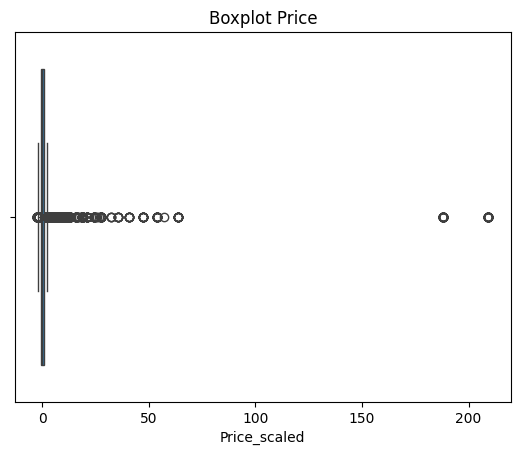

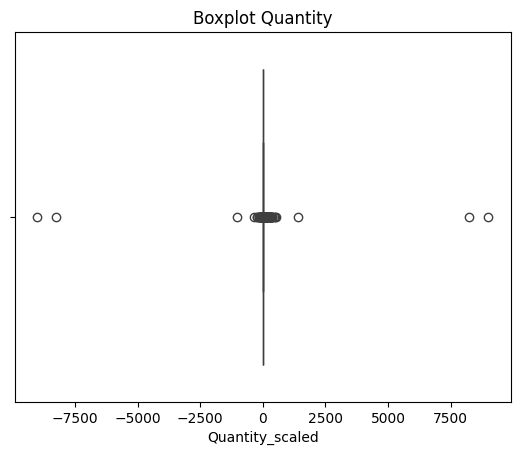

In [26]:
# Boxplot untuk kolom 'price'
sns.boxplot(x=df_clean['Price_scaled'])
plt.title("Boxplot Price")
plt.show()

# Boxplot untuk kolom 'quantity'
sns.boxplot(x=df_clean['Quantity_scaled'])
plt.title("Boxplot Quantity")
plt.show()

Outlier pada dataset transaksi e-commerce merupakan hal yang wajar karena adanya transaksi dalam jumlah besar, return, atau pembelian grosir. Oleh karena itu, outlier tidak langsung dihapus, melainkan dianalisis terlebih dahulu untuk memastikan apakah merupakan kesalahan data atau bagian dari aktivitas bisnis yang valid


Pada dataset ini terdapat nilai Quantity yang bernilai negatif.
Nilai negatif tersebut bukan merupakan kesalahan input, melainkan
menunjukkan adanya transaksipembatalan (cancel) .

Dalam sistem transaksi retail atau e-commerce pada data ini:

*   Quantity positif → menunjukkan jumlah barang yang dibeli.
*   Quantity negatif → menunjukkan barang yang dikembalikan atau transaksi yang dibatalkan.


# Data Manipulation

## Menampilkan data type

In [27]:
df_clean.dtypes

,0
TransactionNo,object
Date,object
ProductNo,object
ProductName,object
Price,float64
Quantity,int64
CustomerNo,float64
Country,object
Price_scaled,float64
Quantity_scaled,float64


Memperbaiki tipe data `Date` dari object menjadi date time

In [28]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%m/%d/%Y')

Mememriksa kembali tipe data

In [29]:
df_clean.dtypes

,0
TransactionNo,object
Date,datetime64[ns]
ProductNo,object
ProductName,object
Price,float64
Quantity,int64
CustomerNo,float64
Country,object
Price_scaled,float64
Quantity_scaled,float64


## Analisis data menggunakan filtering dan sorting

* Filtering Transaksi Penjualan dari transaksi pembatalan

In [30]:
# Filter hanya transaksi dengan Quantity positif (penjualan)
df_sales = df_clean[df_clean['Quantity'] > 0]

df_sales

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Price_scaled,Quantity_scaled
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,3.074194,1.000000
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,-0.416129,3.666667
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,-0.132258,1.000000
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,-0.416129,1.000000
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,0.000000,0.333333
...,...,...,...,...,...,...,...,...,...,...
536320,536585,2018-12-01,37449,Ceramic Cake Stand + Hanging Cakes,20.45,2,17460.0,United Kingdom,2.745161,-0.111111
536321,536590,2018-12-01,22776,Sweetheart 3 Tier Cake Stand,20.45,1,13065.0,United Kingdom,2.745161,-0.222222
536322,536590,2018-12-01,22622,Box Of Vintage Alphabet Blocks,20.45,2,13065.0,United Kingdom,2.745161,-0.111111
536323,536591,2018-12-01,37449,Ceramic Cake Stand + Hanging Cakes,20.45,1,14606.0,United Kingdom,2.745161,-0.222222


Pada data ini, quantity transaksi sebanyak 522.601 transaksi

* Filtering dan sorting transaksi penjualan dari transaksi dengan jumlah pembelian diatas 100

In [31]:
# Transaksi dengan pembelian lebih dari 100 unit
df_sales[df_sales['Quantity'] > 100].sort_values(by='Quantity', ascending=False)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Price_scaled,Quantity_scaled
142,581483,2019-12-09,23843,Paper Craft Little Birdie,12.38,80995,16446.0,United Kingdom,0.141935,8999.111111
473985,541431,2019-01-18,23166,Medium Ceramic Top Storage Jar,11.32,74215,12346.0,United Kingdom,-0.200000,8245.777778
41367,578841,2019-11-25,84826,Asstd Design 3d Paper Stickers,6.19,12540,13256.0,United Kingdom,-1.854839,1393.000000
117790,573008,2019-10-27,84077,World War 2 Gliders Asstd Designs,10.47,4800,12901.0,United Kingdom,-0.474194,533.000000
331834,554868,2019-05-27,22197,Popcorn Holder,10.99,4300,13135.0,United Kingdom,-0.306452,477.444444
...,...,...,...,...,...,...,...,...,...,...
82997,575894,2019-11-11,22070,Small Red Retrospot Mug In Box,10.76,102,12748.0,United Kingdom,-0.380645,11.000000
437434,544776,2019-02-23,22355,Charlotte Bag Suki Design,12.77,102,15776.0,United Kingdom,0.267742,11.000000
76963,576365,2019-11-14,22866,Hand Warmer Scotty Dog Design,15.32,102,14365.0,United Kingdom,1.090323,11.000000
454609,543182,2019-02-04,22174,Photo Cube,13.62,101,16182.0,United Kingdom,0.541935,10.888889


Transaksi dengan pembelian lebih dari 100 unit terdapat 4.845 transaksi, dengan produk Paper Craft Little Birdie paling banyak total pembeliannya

* Harga produk tertinggi pada data

In [32]:
# Mengurutkan berdasarkan Price tertinggi
df_sales.sort_values(by='Price', ascending=False).head(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Price_scaled,Quantity_scaled
465442,542122,2019-01-25,22655,Vintage Red Kitchen Cabinet,660.62,2,17082.0,United Kingdom,209.251613,-0.111111
465441,542102,2019-01-25,22655,Vintage Red Kitchen Cabinet,660.62,2,12744.0,Singapore,209.251613,-0.111111
424516,545902,2019-03-07,22656,Vintage Blue Kitchen Cabinet,660.62,1,15834.0,United Kingdom,209.251613,-0.222222
428398,545543,2019-03-03,22656,Vintage Blue Kitchen Cabinet,660.62,1,13476.0,United Kingdom,209.251613,-0.222222
403361,547814,2019-03-25,22656,Vintage Blue Kitchen Cabinet,660.62,1,13452.0,United Kingdom,209.251613,-0.222222
507609,538662,2018-12-13,22655,Vintage Red Kitchen Cabinet,660.62,2,15159.0,United Kingdom,209.251613,-0.111111
452783,543370,2019-02-07,22656,Vintage Blue Kitchen Cabinet,660.62,1,12359.0,Cyprus,209.251613,-0.222222
507610,538662,2018-12-13,22656,Vintage Blue Kitchen Cabinet,660.62,2,15159.0,United Kingdom,209.251613,-0.111111
432039,545158,2019-02-28,22656,Vintage Blue Kitchen Cabinet,660.62,1,15874.0,United Kingdom,209.251613,-0.222222
484704,540653,2019-01-10,22655,Vintage Red Kitchen Cabinet,660.62,2,17406.0,United Kingdom,209.251613,-0.111111


Vintage Red Kitchen Cabinet menjadi produk termahal pada data ini dengan harga £660.62 Pound Sterling

* Harga produk terendah pada data

In [33]:
# Memeriksa harga terendah pada data
df_sales['Price'].min()

5.13

Harga produk termurah pada data ini sebesar £5.13

In [34]:
# Filter produk dengan harga 5.13
produk_termurah = df_sales[df_sales['Price'] == 5.13]

# Ambil nama produk unik
produk_unik = produk_termurah['ProductName'].unique()

print("Jumlah produk unik dengan harga 5.13:", len(produk_unik))
print("\nDaftar produk unik:")
print(produk_unik)

Jumlah produk unik dengan harga 5.13: 33

Daftar produk unik:
['Lunch Bag Dolly Girl Design' 'Playing Cards Jubilee Union Jack'
 'Set 12 Retro White Chalk Sticks' 'Set 12 Kids White Chalk Sticks'
 'Swallow Wooden Christmas Decoration' 'Small Hanging Ivory/Red Wood Bird'
 'Flower Vine Raffia Food Cover' 'Emergency First Aid Tin'
 'Set Of 6 Snack Loaf Baking Cases' 'Classic Chrome Bicycle Bell'
 'Magic Drawing Slate Bunnies' 'Magic Drawing Slate Leap Frog'
 'Treasure Tin Buffalo Bill' 'Lunch Bag Vintage Leaf Design'
 'Doormat Home Sweet Home Blue' 'Box Of 6 Mini Vintage Crackers'
 '36 Pencils Tube Skulls' 'Lunch Bag Spaceboy Design'
 'Wicker Wreath Large' 'Treasure Tin Gymkhana Design'
 'Round Storage Tin Vintage Leaf' 'Childrens Dolly Girl Mug'
 'Set Of 6 Cake Chopsticks' 'Set Of 6 Strawberry Chopsticks'
 'Christmas Craft Little Friends' 'Jumbo Storage Bag Suki'
 '15cm Christmas Glass Ball 20 Lights' 'Jumbo Bag Spaceboy Design'
 'Jumbo Bag Strawberry' 'Jumbo Bag Red Retrospot' 'Jumbo Ba

terdapat produk dengan harga terendah yaitu sebesar £5.13 sebanyak 33 produk

In [35]:
# Mengurutkan berdasarkan Price terendah
df_sales.sort_values(by='Price', ascending=True).head(33)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Price_scaled,Quantity_scaled
345543,553539,2019-05-17,20711,Jumbo Bag Toys,5.13,1,17539.0,United Kingdom,-2.196774,-0.222222
345227,553521,2019-05-17,85099F,Jumbo Bag Strawberry,5.13,1,15521.0,United Kingdom,-2.196774,-0.222222
495484,539856,2018-12-22,85099B,Jumbo Bag Red Retrospot,5.13,1,16856.0,United Kingdom,-2.196774,-0.222222
100534,574469,2019-11-04,22385,Jumbo Bag Spaceboy Design,5.13,12,12431.0,Australia,-2.196774,1.000000
28579,579885,2019-11-30,22532,Magic Drawing Slate Leap Frog,5.13,2,15444.0,United Kingdom,-2.196774,-0.111111
28578,579885,2019-11-30,22535,Magic Drawing Slate Bunnies,5.13,2,15444.0,United Kingdom,-2.196774,-0.111111
29735,579387,2019-11-29,23318,Box Of 6 Mini Vintage Crackers,5.13,4,14452.0,United Kingdom,-2.196774,0.111111
29734,579387,2019-11-29,22690,Doormat Home Sweet Home Blue,5.13,1,14452.0,United Kingdom,-2.196774,-0.222222
10666,580914,2019-12-06,21916,Set 12 Retro White Chalk Sticks,5.13,3,14871.0,United Kingdom,-2.196774,0.000000
10665,580914,2019-12-06,23504,Playing Cards Jubilee Union Jack,5.13,2,14871.0,United Kingdom,-2.196774,-0.111111


* Filtering Transaksi Penjualan yang dibatalkan

In [36]:
# Filter hanya transaksi dengan Quantity negatif (penjualan)
df_sales_batal = df_clean[df_clean['Quantity'] < 0]

df_sales_batal

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Price_scaled,Quantity_scaled
1616,C581484,2019-12-09,23843,Paper Craft Little Birdie,6.19,-80995,16446.0,United Kingdom,-1.854839,-8999.777778
1617,C581490,2019-12-09,22178,Victorian Glass Hanging T-Light,6.19,-12,14397.0,United Kingdom,-1.854839,-1.666667
1618,C581490,2019-12-09,23144,Zinc T-Light Holder Stars Small,6.04,-11,14397.0,United Kingdom,-1.903226,-1.555556
1619,C581568,2019-12-09,21258,Victorian Sewing Box Large,6.19,-5,15311.0,United Kingdom,-1.854839,-0.888889
1620,C581569,2019-12-09,84978,Hanging Heart Jar T-Light Holder,6.19,-1,17315.0,United Kingdom,-1.854839,-0.444444
...,...,...,...,...,...,...,...,...,...,...
536345,C536548,2018-12-01,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany,2.264516,-0.555556
536346,C536548,2018-12-01,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany,0.693548,-0.666667
536347,C536548,2018-12-01,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany,-0.064516,-0.444444
536348,C536548,2018-12-01,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany,1.422581,-0.777778


Terdapat sekitar 8.494 penjualan yang dibatalkan oleh pelanggan

## Analisis data menggunakan grouping

### completed

In [37]:
# Salin + filter langsung tanpa menimpa lagi
df_sales = df_clean[df_clean['Quantity'] > 0].copy()


In [38]:
# df_sales.to_excel("finalbgtt_complete_project.xlsx", index=False)

* Top produk terlaris dari total quantity per produk

In [39]:
# Menghitung total Quantity per produk
top_products = (
    df_sales.groupby('ProductName')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Quantity
ProductName,
Paper Craft Little Birdie,80995
Medium Ceramic Top Storage Jar,78033
Popcorn Holder,56902
World War 2 Gliders Asstd Designs,54951
Jumbo Bag Red Retrospot,48375
Cream Hanging Heart T-Light Holder,37937
Pack Of 72 Retrospot Cake Cases,36492
Assorted Colour Bird Ornament,36394
Rabbit Night Light,30742


* Produk paling tidak laris dari total quantity per produk

In [40]:
# Menghitung total Quantity per produk
low_products = (
    df_sales.groupby('ProductName')['Quantity']
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

low_products

,Quantity
ProductName,
Wire Flower T-Light Holder,1
Dolphin Windmill,1
Gardeners Kneeling Pad,1
Funky Monkey Mug,1
Set Of Three Vintage Gift Wraps,1
Set Of 3 Pink Flying Ducks,1
Black Glass/Shell/Pearl Necklace,1
Gold Cosmetics Bag With Butterfly,1
Crochet Lilac/Red Bear Keyring,1


* Top produk yang paling sering dibeli dengan transaksi paling banyak

In [41]:
top_freq = (
    df_sales[df_sales['Quantity'] > 0]   # filter bukan pembatalan
    .groupby('ProductName')
    .agg(Total_Transaksi=('TransactionNo', 'nunique'))
    .sort_values(by='Total_Transaksi', ascending=False)
    .head(10)
)

top_freq

,Total_Transaksi
ProductName,
Cream Hanging Heart T-Light Holder,2269
Jumbo Bag Red Retrospot,2092
Regency Cakestand 3 Tier,1989
Party Bunting,1687
Lunch Bag Red Retrospot,1567
Assorted Colour Bird Ornament,1457
Popcorn Holder,1392
Set Of 3 Cake Tins Pantry Design,1385
Pack Of 72 Retrospot Cake Cases,1322


* Top negara dengan jumlah transaksi terbesar

In [75]:
transaksi_per_negara = (
    df_sales
    .groupby('Country')
    .agg(Jumlah_customer=('CustomerNo', 'nunique'))
    .sort_values(by='Jumlah_customer', ascending=False)
)

transaksi_per_negara.head(10)

,Jumlah_customer
Country,
United Kingdom,4305
Germany,91
France,87
Spain,23
Belgium,22
Switzerland,21
Portugal,18
EIRE,13
Italy,12


UK atau United Kingdom menempati urutan pertama dengan jumlah transaksi paling besar

* Jumlah Hari Sejak Pembelian Terakhir Pelanggan

In [43]:
import pandas as pd

# menentukan tanggal analisis
analysis_date = df_sales['Date'].max() + pd.Timedelta(days=1)

# menghitung recency
recency = (
    df_sales
    .groupby('CustomerNo')['Date']
    .max()
    .reset_index()
)

recency['Recency'] = (analysis_date - recency['Date']).dt.days

recency.head()

,CustomerNo,Date,Recency
0,12004.0,2019-04-26,228
1,12006.0,2019-05-05,219
2,12008.0,2019-03-08,277
3,12013.0,2018-12-15,360
4,12024.0,2019-06-16,177


### canceled

In [44]:
# Filter transaksi dengan Quantity negatif (pembatalan) dan buat salinan
df_sales_batal = df_clean[df_clean['Quantity'] < 0].copy()

# Cek hasil
df_sales_batal.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Price_scaled,Quantity_scaled
1616,C581484,2019-12-09,23843,Paper Craft Little Birdie,6.19,-80995,16446.0,United Kingdom,-1.854839,-8999.777778
1617,C581490,2019-12-09,22178,Victorian Glass Hanging T-Light,6.19,-12,14397.0,United Kingdom,-1.854839,-1.666667
1618,C581490,2019-12-09,23144,Zinc T-Light Holder Stars Small,6.04,-11,14397.0,United Kingdom,-1.903226,-1.555556
1619,C581568,2019-12-09,21258,Victorian Sewing Box Large,6.19,-5,15311.0,United Kingdom,-1.854839,-0.888889
1620,C581569,2019-12-09,84978,Hanging Heart Jar T-Light Holder,6.19,-1,17315.0,United Kingdom,-1.854839,-0.444444


* Top produk transaksi batal

In [45]:
# Analisis produk dengan frekuensi pembatalan tertinggi

top_freq_batal = (
    df_sales_batal
    # Mengelompokkan data berdasarkan nama produk
    .groupby('ProductName')

    # Menghitung jumlah transaksi unik (TransactionNo)
    # nunique() digunakan agar tidak menghitung transaksi yang sama lebih dari sekali
    .agg(Jumlah_Pembatalan=('TransactionNo', 'nunique'))

    # Mengurutkan dari jumlah pembatalan terbesar ke terkecil
    .sort_values(by='Jumlah_Pembatalan', ascending=False)

    # Menampilkan 10 produk dengan pembatalan terbanyak
    .head(10)
)

top_freq_batal

,Jumlah_Pembatalan
ProductName,
Regency Cakestand 3 Tier,180
Jam Making Set With Jars,86
Set Of 3 Cake Tins Pantry Design,72
Strawberry Ceramic Trinket Pot,57
Roses Regency Teacup And Saucer,53
Popcorn Holder,50
Recipe Box Pantry Yellow Design,47
Jumbo Bag Red Retrospot,43
Cream Hanging Heart T-Light Holder,42


* Top produk transaksi batal dengan quantity terbesar

In [46]:
top_cancel_product = (
    df_sales_batal
    .groupby('ProductName')['Quantity']
    .sum()
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)

top_cancel_product.head(10)

,ProductName,Quantity
0,Paper Craft Little Birdie,80995
1,Medium Ceramic Top Storage Jar,74494
2,Rotating Silver Angels T-Light Hldr,9367
3,Fairy Cake Flannel Assorted Colour,3150
4,Cream Hanging Heart T-Light Holder,2578
5,Gin And Tonic Diet Metal Sign,2030
6,Herb Marker Basil,1527
7,Feltcraft Doll Molly,1447
8,Tea Time Party Bunting,1424
9,Paper Pocket Traveling Fan,1385


In [47]:
# menghitung rata-rata harga tiap produk
avg_price_product = df_clean.groupby('ProductName')['Price'].mean().reset_index()

# gabungkan dengan top cancel product
cancel_price_analysis = top_cancel_product.merge(avg_price_product, on='ProductName')

cancel_price_analysis.head(10)

,ProductName,Quantity,Price
0,Paper Craft Little Birdie,80995,9.285000
1,Medium Ceramic Top Storage Jar,74494,11.122038
2,Rotating Silver Angels T-Light Hldr,9367,12.259552
3,Fairy Cake Flannel Assorted Colour,3150,11.783271
4,Cream Hanging Heart T-Light Holder,2578,13.078939
5,Gin And Tonic Diet Metal Sign,2030,12.533370
6,Herb Marker Basil,1527,10.737195
7,Feltcraft Doll Molly,1447,12.688673
8,Tea Time Party Bunting,1424,16.488589
9,Paper Pocket Traveling Fan,1385,10.371901


Analisis terhadap produk dengan jumlah pembatalan tertinggi menunjukkan bahwa harga rata-rata produk tersebut berada pada kisaran yang relatif moderat. Hal ini menunjukkan bahwa tingginya tingkat pembatalan kemungkinan tidak disebabkan oleh faktor harga produk. Oleh karena itu, kemungkinan penyebab pembatalan dapat berasal dari faktor lain seperti kesalahan pemesanan, ketidaksesuaian produk dengan ekspektasi pelanggan, atau proses pengiriman.

In [48]:
# Hitung jumlah transaksi unik per customer
top10_customer_transaksi = (
    df_sales_batal.groupby('CustomerNo')['TransactionNo']
    .nunique()  # hitung transaksi unik
    .sort_values(ascending=False)
    .head(10)
)

top10_customer_transaksi

,TransactionNo
CustomerNo,
17841.0,45
14911.0,43
14606.0,35
15311.0,27
13089.0,21
13534.0,18
12471.0,18
13078.0,17
13767.0,15


In [49]:
df_sales_batal[df_sales_batal['CustomerNo'] == 16446][['ProductName','Quantity', 'TransactionNo', 'Date', 'ProductNo', 'Price', 'Country']]

,ProductName,Quantity,TransactionNo,Date,ProductNo,Price,Country
1616,Paper Craft Little Birdie,-80995,C581484,2019-12-09,23843,6.19,United Kingdom


In [50]:
# Total quantity pembatalan per customer
total_qty_per_customer = (
    df_sales_batal.groupby('CustomerNo')['Quantity']
    .sum()
    .abs()
)

# Jumlah transaksi unik per customer
total_transaksi_per_customer = (
    df_sales_batal.groupby('CustomerNo')['TransactionNo']
    .nunique()
)

# Gabungkan menjadi satu dataframe
customer_batal_summary = pd.DataFrame({
    'Total_Quantity': total_qty_per_customer,
    'Jumlah_Transaksi': total_transaksi_per_customer
})

# Urut berdasarkan Total_Quantity terbanyak dan ambil top 10
top10_customer_batal = customer_batal_summary.sort_values(by='Total_Quantity', ascending=False).head(10)

top10_customer_batal

,Total_Quantity,Jumlah_Transaksi
CustomerNo,,
16446.0,80995,1
12346.0,74215,1
15838.0,9360,1
15749.0,9014,1
16029.0,6420,4
12931.0,4427,4
14607.0,3768,3
14911.0,3324,43
17949.0,2878,5


Tingginya jumlah pembatalan pada beberapa produk ternyata dipengaruhi oleh pembatalan dalam jumlah besar yang dilakukan oleh beberapa pelanggan tertentu. Sebagai contoh, pelanggan dengan ID 16446 melakukan pembatalan hingga 80.995 unit produk, yang secara signifikan mempengaruhi total jumlah pembatalan pada produk terkait

- Cancel tinggi karena bulk cancel oleh customer tertentu
- Bukan karena produk sering dibatalkan oleh banyak pelanggan

In [51]:
transaksi_batal_per_negara = (
    df_sales_batal
    .groupby('Country')
    .agg(Jumlah_Transaksi=('TransactionNo', 'nunique'))
    .sort_values(by='Jumlah_Transaksi', ascending=False)
)

transaksi_batal_per_negara.head(10)

,Jumlah_Transaksi
Country,
United Kingdom,3011
Germany,134
France,59
EIRE,55
Switzerland,18
Belgium,17
Italy,12
Spain,11
Australia,11


Sebagian besar transaksi terjadi di United Kingdom, yang juga menjadi negara dengan jumlah pembatalan transaksi tertinggi. Hal ini kemungkinan disebabkan oleh tingginya volume transaksi yang terjadi di negara tersebut. Dengan kata lain, tingginya jumlah pembatalan di United Kingdom tidak selalu menunjukkan adanya masalah khusus, tetapi lebih dipengaruhi oleh jumlah transaksi yang memang jauh lebih besar dibandingkan negara lainnya.

## Membuat kolom baru

### RFM

* Membuat kolom baru menambahkan `Year`, `Month`, `Year`, `Day Name`

In [52]:
df_sales['Year'] = df_sales['Date'].dt.year
df_sales['Month'] = df_sales['Date'].dt.month
df_sales['Day'] = df_sales['Date'].dt.day
df_sales['Day_Name'] = df_sales['Date'].dt.day_name()

df_sales.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Price_scaled,Quantity_scaled,Year,Month,Day,Day_Name
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,3.074194,1.000000,2019,12,9,Monday
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,-0.416129,3.666667,2019,12,9,Monday
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,-0.132258,1.000000,2019,12,9,Monday
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,-0.416129,1.000000,2019,12,9,Monday
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,0.000000,0.333333,2019,12,9,Monday


* Membuat kolom baru menghitung Revenue

In [53]:
df_sales['Revenue'] = df_sales['Price'] * df_sales['Quantity']

* Memeriksa Tanggal Minimum dan Maksimum pada data

In [54]:
min_date = df_sales['Date'].min()
max_date = df_sales['Date'].max()

print("Tanggal paling awal :", min_date)
print("Tanggal paling akhir:", max_date)

Tanggal paling awal : 2018-12-01 00:00:00
Tanggal paling akhir: 2019-12-09 00:00:00


- Tanggal transaksi terakhir pada dataset adalah 9 Desember 2019.
- Tanggal ini digunakan sebagai patokan waktu untuk melihat kapan terakhir kali pelanggan melakukan pembelian.

In [55]:
snapshot_date = df_sales['Date'].max()

* Hitung RFM

In [56]:
# --- RFM calculation menggunakan Revenue_Completed ---
rfm = df_sales.groupby('CustomerNo').agg({
    'Date': lambda x: (snapshot_date - x.max()).days,   # Recency
    'TransactionNo': 'nunique',                         # Frequency
    'Revenue': 'sum'                          # Monetary (hanya transaksi sukses)
}).reset_index()

# Rename columns
rfm.columns = ['CustomerNo','Recency','Frequency','Monetary']

* hasil statistik

In [57]:
# Statistik deskriptif untuk Revenue, Price, dan Quantity
df_sales[['Revenue', 'Price', 'Quantity']].describe()

,Revenue,Price,Quantity
count,5.226010e+05,522601.000000,522601.000000
mean,1.201324e+02,12.637160,10.667492
std,1.860159e+03,7.965974,157.542420
min,5.130000e+00,5.130000,1.000000
25%,1.790000e+01,10.990000,1.000000
50%,4.448000e+01,11.940000,4.000000
75%,1.208000e+02,14.090000,12.000000
max,1.002718e+06,660.620000,80995.000000


* RFM

In [58]:
def recency_segment(x):
    if x >= 180:
        return 'Lost'
    elif x >= 90:
        return 'At Risk'
    elif x >= 30:
        return 'Potential'
    else:
        return 'Royal'

def frequency_segment(x):
    if x <= 1:
        return 'Lost'
    elif x <= 4:
        return 'At Risk'
    elif x <= 12:
        return 'Potential'
    else:
        return 'Royal'

def monetary_segment(x):
    if x <= 250000:
        return 'Lost'
    elif x <= 500000:
        return 'At Risk'
    elif x <= 750000:
        return 'Potential'
    else:  # 750k < x <= 1,000,000
        return 'Royal'

# --- Terapkan segmentasi ---
rfm['R_segment'] = rfm['Recency'].apply(recency_segment)
rfm['F_segment'] = rfm['Frequency'].apply(frequency_segment)
rfm['M_segment'] = rfm['Monetary'].apply(monetary_segment)

# --- Gabungkan menjadi satu RFM segment ---
def rfm_combined(row):
    if row['R_segment']=='Royal' or row['M_segment']=='Royal' or row['F_segment']=='Royal':
        return 'Royal'
    elif row['R_segment']=='Potential' or row['M_segment']=='Potential' or row['F_segment']=='Potential':
        return 'Potential'
    elif row['R_segment']=='At Risk' or row['M_segment']=='At Risk' or row['F_segment']=='At Risk':
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(rfm_combined, axis=1)

# --- Cek hasil ---
rfm.head()

,CustomerNo,Recency,Frequency,Monetary,R_segment,F_segment,M_segment,Segment
0,12004.0,227,1,1509.60,Lost,Lost,Lost,Lost
1,12006.0,218,1,24.76,Lost,Lost,Lost,Lost
2,12008.0,276,1,5689.57,Lost,Lost,Lost,Lost
3,12013.0,359,1,69.96,Lost,Lost,Lost,Lost
4,12024.0,176,1,149.52,At Risk,Lost,Lost,At Risk


* Menentukan segment dari recency

| Recency                   | Segment   |
| ------------------------- | --------- |
| ≤ 30 hari (± 1 bulan)     | Royal     |
| 31 – 90 hari (1–3 bulan)  | Potential |
| 91 – 180 hari (3–6 bulan) | At Risk   |
| ≥ 180 hari (≥ 6 bulan)    | Lost      |

* Penentuan segmentasi frekuency dilakukan menggunakan nilai minimum dan distribusi quantile dari data transaksi.
1. Lost (≤ 1 transaksi)
Batas ≤ 1 dipilih karena nilai minimum dan Q1 sama-sama bernilai 1.
Artinya sekitar 25% pelanggan hanya melakukan 1 transaksi.
2. At Risk (2 – 4 transaksi)
Batas atas 4 transaksi diambil dari nilai median (50%). Ini menunjukkan bahwa setengah dari pelanggan melakukan transaksi maksimal 4 kali.
3. Potential (5 – 12 transaksi)
Batas 12 transaksi berasal dari nilai Q3 (75%). Artinya 75% pelanggan memiliki frekuensi transaksi sampai 12 kali.
4. Royal (> 12 transaksi)
Nilai > 12 dipilih karena berada di atas Q3, yaitu kelompok pelanggan dengan frekuensi transaksi tertinggi.
Segmen ini mewakili sekitar 25% pelanggan dengan aktivitas transaksi paling tinggi.

- Penentuan segmentasi monetary menggunakan rentang minimum dan maximum
Berdasarkan hasil statistik deskriptif:
* Minimum revenue = 5.13
* Maximum revenue = 1,002,718
| Monetary (Revenue) | Segment   |
| ------------------ | --------- |
| ≤ 250,000          | Lost      |
| 250,001 – 500,000  | At Risk   |
| 500,001 – 750,000  | Potential |
| > 750,000          | Royal     |


* Menggabungkan dengan tabel df_sales

In [59]:
df_sales = df_sales.merge(
    rfm[['CustomerNo', 'Segment']],
    on='CustomerNo',
    how='left'
)

In [60]:
df_sales.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Price_scaled,Quantity_scaled,Year,Month,Day,Day_Name,Revenue,Segment
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,3.074194,1.000000,2019,12,9,Monday,257.64,Royal
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,-0.416129,3.666667,2019,12,9,Monday,383.40,Royal
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,-0.132258,1.000000,2019,12,9,Monday,138.36,Royal
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,-0.416129,1.000000,2019,12,9,Monday,127.80,Royal
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,0.000000,0.333333,2019,12,9,Monday,71.64,Royal


In [62]:
# df_sales.to_excel("terakhirr_beneran_project.xlsx", index=False)

* Distribusi Segment

In [63]:
segment_customer = df_sales.groupby('Segment')['CustomerNo'].nunique().sort_values(ascending=False)

segment_customer

,CustomerNo
Segment,
Royal,1737
Potential,1384
At Risk,880
Lost,717


## Data Setelah Cleaning

In [64]:
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['Day_Name'] = df_clean['Date'].dt.day_name()

df_clean.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Price_scaled,Quantity_scaled,Year,Month,Day,Day_Name
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,3.074194,1.000000,2019,12,9,Monday
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,-0.416129,3.666667,2019,12,9,Monday
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,-0.132258,1.000000,2019,12,9,Monday
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,-0.416129,1.000000,2019,12,9,Monday
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,0.000000,0.333333,2019,12,9,Monday


Kolom Revenue dibuat untuk menghitung total nilai penjualan pada setiap transaksi.

Rumus yang digunakan:

* Revenue = Price × Quantity

Perhitungan ini dilakukan pada dataset df_sales, yaitu dataset yang hanya
berisi transaksi dengan Quantity positif. Hal ini dilakukan agar revenue
yang dianalisis hanya berasal dari transaksi penjualan yang berhasil dan
tidak termasuk transaksi pembatalan

In [65]:
# --- 1. Revenue per status ---
df_clean['Revenue_Completed'] = df_clean.apply(lambda x: x['Price']*x['Quantity'] if x['Quantity']>0 else 0, axis=1)
df_clean['Revenue_Canceled']  = df_clean.apply(lambda x: x['Price']*abs(x['Quantity']) if x['Quantity']<0 else 0, axis=1)

In [66]:
# --- 2. Kolom Status ---
df_clean['Status'] = df_clean['Quantity'].apply(lambda x: 'Completed' if x>0 else 'Canceled')

In [67]:
df_clean.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Price_scaled,Quantity_scaled,Year,Month,Day,Day_Name,Revenue_Completed,Revenue_Canceled,Status
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,3.074194,1.000000,2019,12,9,Monday,257.64,0.0,Completed
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,-0.416129,3.666667,2019,12,9,Monday,383.40,0.0,Completed
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,-0.132258,1.000000,2019,12,9,Monday,138.36,0.0,Completed
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,-0.416129,1.000000,2019,12,9,Monday,127.80,0.0,Completed
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,0.000000,0.333333,2019,12,9,Monday,71.64,0.0,Completed


In [68]:
# --- 1. Pisahkan Quantity ---
df_clean['Quantity_Completed'] = df_clean['Quantity'].apply(lambda x: x if x>0 else 0)
df_clean['Quantity_Canceled']  = df_clean['Quantity'].apply(lambda x: abs(x) if x<0 else 0)

In [69]:
df_clean.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Price_scaled,Quantity_scaled,Year,Month,Day,Day_Name,Revenue_Completed,Revenue_Canceled,Status,Quantity_Completed,Quantity_Canceled
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,3.074194,1.000000,2019,12,9,Monday,257.64,0.0,Completed,12,0
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,-0.416129,3.666667,2019,12,9,Monday,383.40,0.0,Completed,36,0
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,-0.132258,1.000000,2019,12,9,Monday,138.36,0.0,Completed,12,0
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,-0.416129,1.000000,2019,12,9,Monday,127.80,0.0,Completed,12,0
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,0.000000,0.333333,2019,12,9,Monday,71.64,0.0,Completed,6,0


In [70]:
# df_clean.to_excel("final_beneran_project.xlsx", index=False)

# Encoding

In [ ]:
df_encode = df_clean.copy()

In [ ]:
freq_encoding = df_clean['ProductName'].value_counts()

df_clean['ProductName_encoded'] = df_clean['ProductName'].map(freq_encoding)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean['Country_encoded'] = le.fit_transform(df_clean['Country'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le1 = LabelEncoder()
df_clean['Day_Name_encoded'] = le1.fit_transform(df_clean['Day_Name'])

In [ ]:
segment_mapping = {
    'Lost': 0,
    'At Risk': 1,
    'Potential Customer': 2,
    'Loyal Customer': 3
}

df_clean['Segment_encoded'] = df_clean['Segment'].map(segment_mapping)

In [ ]:
# Kolom hasil encoding
encoding = [
    'ProductName_encoded',
    'Country_encoded',
]


In [ ]:
non_encoding = [
    'TransactionNo',
    'ProductNo',
    'Price',
    'Quantity',
    'CustomerNo'
]

In [ ]:
df_final = df_clean[non_encoding + encoding]

df_final.head()

,TransactionNo,ProductNo,Price,Quantity,CustomerNo,ProductName_encoded,Country_encoded
0,581482,22485,21.47,12,17490.0,212,36
1,581475,22596,10.65,36,13069.0,271,36
2,581475,23235,11.53,12,13069.0,112,36
3,581475,23272,10.65,12,13069.0,44,36
4,581475,23239,11.94,6,13069.0,190,36


# EDA

## Heatmap

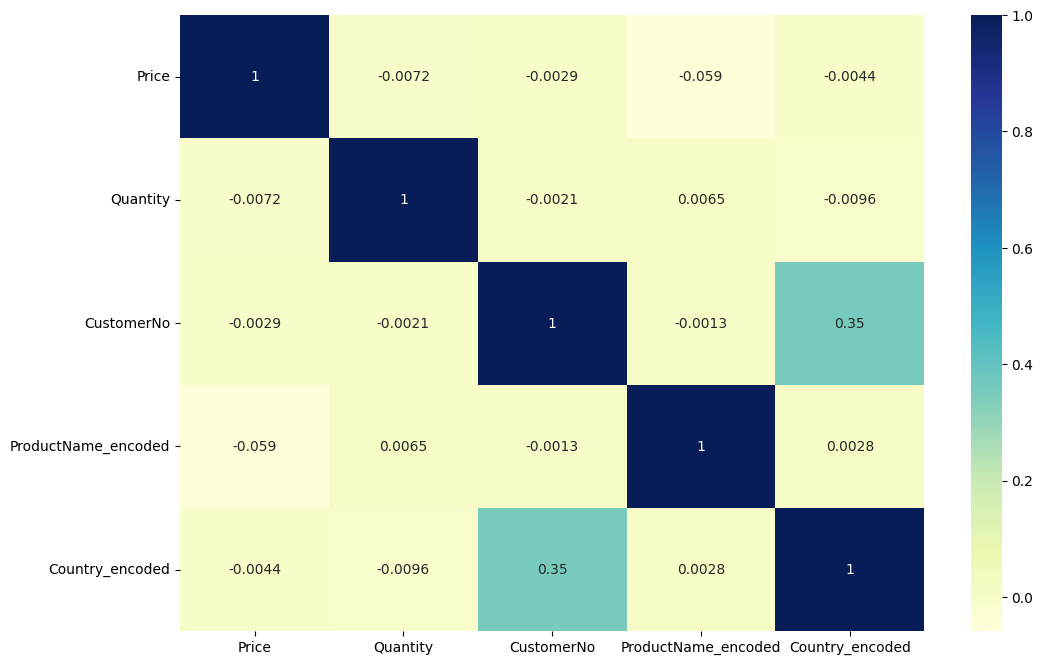

In [ ]:
plt.figure(figsize=(12, 8))

# Hitung matriks korelasi
co_mtx = df_final.corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Menampilkan heatmap
plt.show()

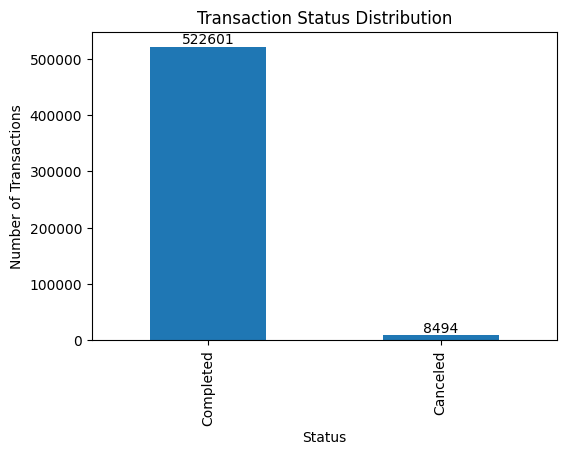

In [73]:
import matplotlib.pyplot as plt

status_counts = df_clean['Status'].value_counts()

plt.figure(figsize=(6,4))
ax = status_counts.plot(kind='bar')

# anotasi
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Transaction Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Transactions')

plt.show()

## Completed

### Top 10 Produk dengan Jumlah Pelanggan Terbanyak

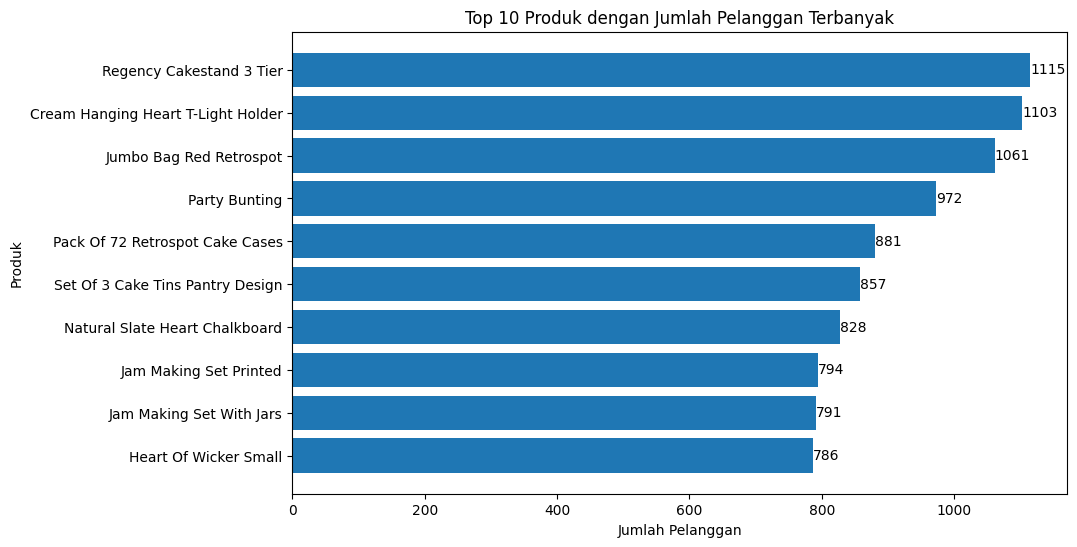

In [ ]:
import matplotlib.pyplot as plt

# Menghitung jumlah unik pelanggan per produk
top_customers_products = (
    df_sales
    .groupby('ProductName')['CustomerNo']  # Kelompokkan berdasarkan produk
    .nunique()                             # Hitung jumlah pelanggan unik
    .sort_values(ascending=False)          # Urutkan dari terbesar ke terkecil
    .head(10)                              # Ambil 10 produk teratas
)

plt.figure(figsize=(10,6))

# Membuat bar chart horizontal
bars = plt.barh(
    top_customers_products.index,  # Nama produk
    top_customers_products.values  # Jumlah pelanggan
)

# Membalik urutan agar produk dengan pelanggan terbanyak berada di atas
plt.gca().invert_yaxis()

# Judul dan label
plt.title("Top 10 Produk dengan Jumlah Pelanggan Terbanyak")
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Produk")

# Menambahkan anotasi
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",  # Format angka sebagai integer
        va='center'
    )

plt.show()

### Tren Jumlah Pelanggan setiap bulan

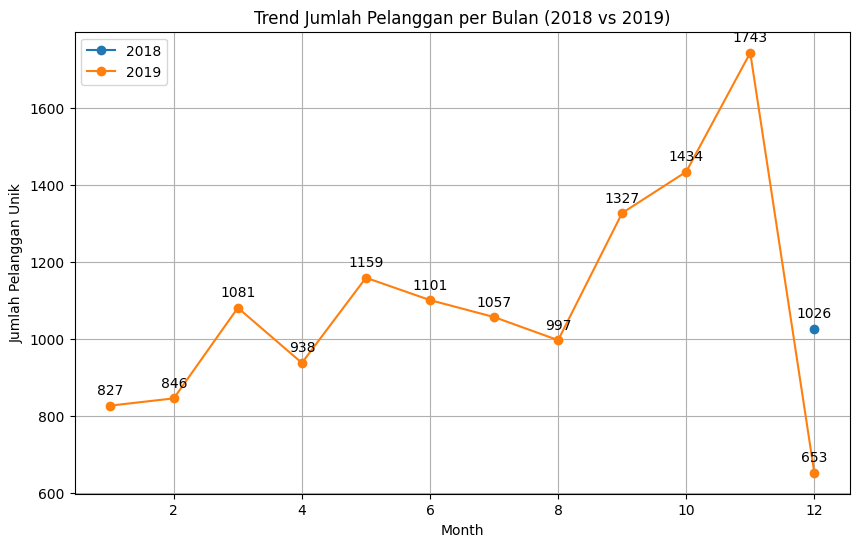

In [ ]:
import matplotlib.pyplot as plt

# Menghitung jumlah pelanggan unik per tahun dan bulan
monthly_customers = (
    df_sales
    .groupby(['Year','Month'])['CustomerNo']  # Kelompokkan berdasarkan tahun dan bulan
    .nunique()                                # Hitung jumlah pelanggan unik
    .reset_index()
)

plt.figure(figsize=(10,6))

# Filter data berdasarkan tahun
data_2018 = monthly_customers[monthly_customers['Year'] == 2018]
data_2019 = monthly_customers[monthly_customers['Year'] == 2019]

# 2018
plt.plot(
    data_2018['Month'],
    data_2018['CustomerNo'],
    marker='o',
    label='2018'
)

# Anotasi titik 2018
for i in range(len(data_2018)):
    plt.annotate(
        f"{int(data_2018['CustomerNo'].iloc[i])}",
        (data_2018['Month'].iloc[i], data_2018['CustomerNo'].iloc[i]),
        textcoords="offset points",
        xytext=(0,8),
        ha='center'
    )

# 2019
plt.plot(
    data_2019['Month'],
    data_2019['CustomerNo'],
    marker='o',
    label='2019'
)

# Anotasi titik 2019
for i in range(len(data_2019)):
    plt.annotate(
        f"{int(data_2019['CustomerNo'].iloc[i])}",
        (data_2019['Month'].iloc[i], data_2019['CustomerNo'].iloc[i]),
        textcoords="offset points",
        xytext=(0,8),
        ha='center'
    )

plt.title("Trend Jumlah Pelanggan per Bulan (2018 vs 2019)")
plt.xlabel("Month")
plt.ylabel("Jumlah Pelanggan Unik")
plt.legend()
plt.grid(True)

plt.show()

### Trend Jumlah Pelanggan dalam Seminggu

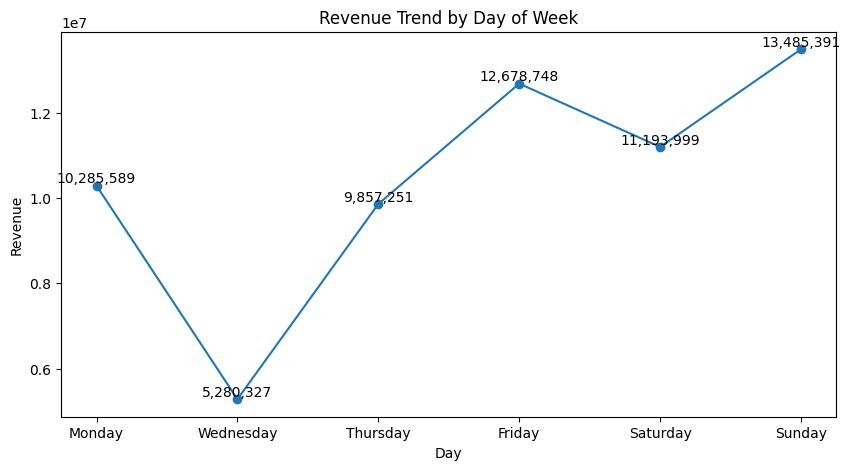

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Total pelanggan unik per hari
day_customers = (
    df_sales
    .groupby('Day_Name')['CustomerNo']
    .nunique()  # hitung jumlah pelanggan unik
    .reset_index()
)

# Urutan hari supaya tidak acak
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_customers['Day_Name'] = pd.Categorical(day_customers['Day_Name'], categories=order, ordered=True)
day_customers = day_customers.sort_values('Day_Name')

plt.figure(figsize=(10,5))
plt.plot(day_customers['Day_Name'], day_customers['CustomerNo'], marker='o')

# Menambahkan anotasi
for x, y in zip(day_customers['Day_Name'], day_customers['CustomerNo']):
    plt.text(x, y, f'{int(y)}', ha='center', va='bottom')

plt.title("Trend Jumlah Pelanggan per Hari dalam Seminggu")
plt.xlabel("Hari")
plt.ylabel("Jumlah Pelanggan Unik")

plt.show()

### Top 10 Negara dengan revenue terbesar

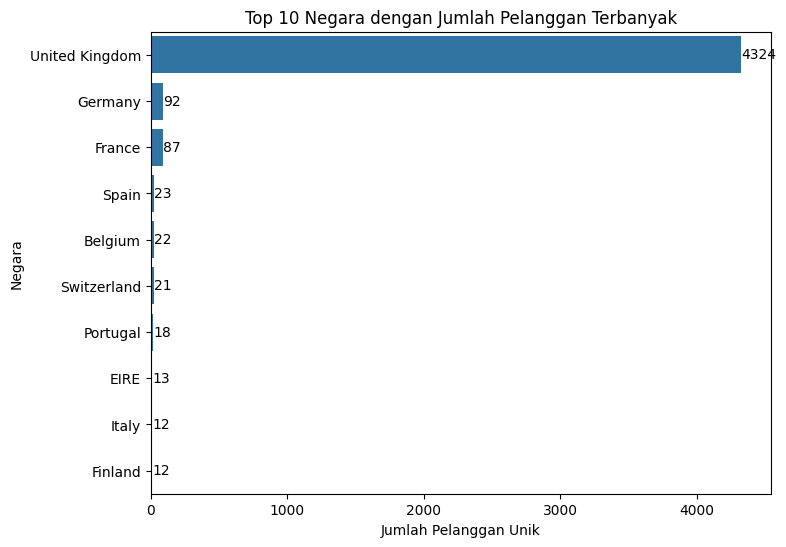

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Menghitung jumlah pelanggan unik per negara
top_country_customers = (
    df_sales
    .groupby('Country')['CustomerNo']
    .nunique()  # hitung jumlah pelanggan unik
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_country_customers,
    x='CustomerNo',
    y='Country'
)

# Judul dan label sumbu
plt.title("Top 10 Negara dengan Jumlah Pelanggan Terbanyak")
plt.xlabel("Jumlah Pelanggan Unik")
plt.ylabel("Negara")

# Menambahkan anotasi jumlah pelanggan di setiap bar
for i, v in enumerate(top_country_customers['CustomerNo']):
    plt.text(v, i, f"{v}", va='center')

plt.show()

* Analisis Purchase Frequency per Customer

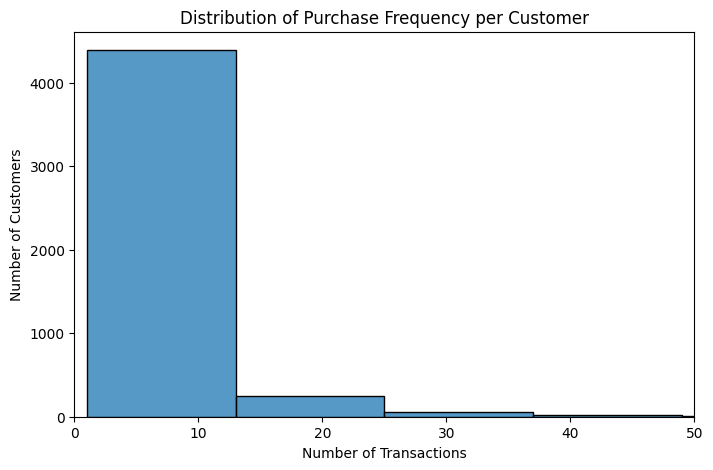

In [ ]:
purchase_freq = df_sales.groupby('CustomerNo')['TransactionNo'].nunique()

plt.figure(figsize=(8,5))
sns.histplot(purchase_freq, bins=20)

plt.title("Distribution of Purchase Frequency per Customer")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

# Batasi range transaksi agar distribusi lebih terlihat
plt.xlim(0, 50)

plt.show()

- Distribusi frekuensi pembelian menunjukkan bahwa mayoritas pelanggan hanya melakukan sedikit transaksi, sementara hanya sebagian kecil pelanggan yang melakukan pembelian secara berulang dengan frekuensi tinggi
- Banyak pelanggan kemungkinan merupakan one-time buyer atau low frequency buyer

### Distribusi rata-rata recency (Jumlah Hari Sejak Pembelian Terakhir Pelanggan)

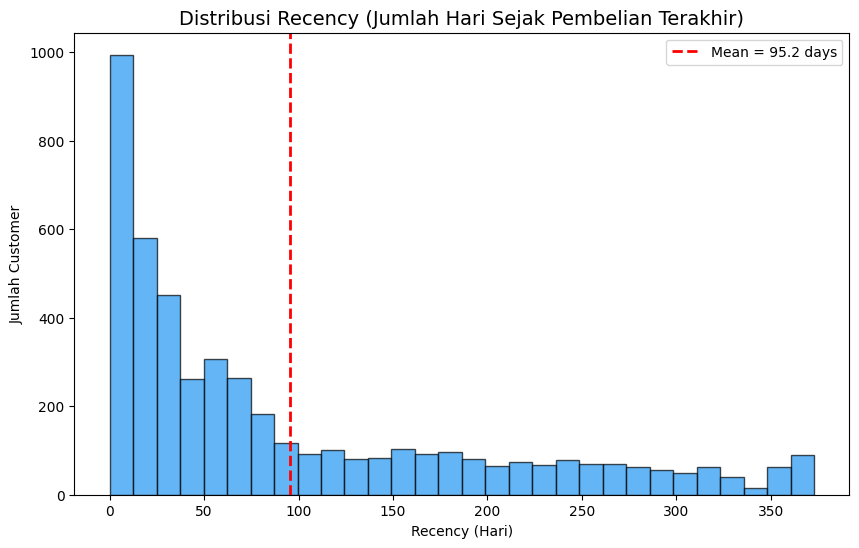

In [ ]:
import matplotlib.pyplot as plt

# Hitung rata-rata Recency
mean_recency = rfm['Recency'].mean()

# Buat histogram
plt.figure(figsize=(10,6))
plt.hist(rfm['Recency'], bins=30, color='#2196F3', alpha=0.7, edgecolor='black')

# Tambahkan garis rata-rata
plt.axvline(mean_recency, color='red', linestyle='dashed', linewidth=2, label=f'Mean = {mean_recency:.1f} days')

# Label dan judul
plt.title("Distribusi Recency (Jumlah Hari Sejak Pembelian Terakhir)", fontsize=14)
plt.xlabel("Recency (Hari)")
plt.ylabel("Jumlah Customer")
plt.legend()
plt.show()

### Distribusi segmen

In [58]:
!pip install squarify

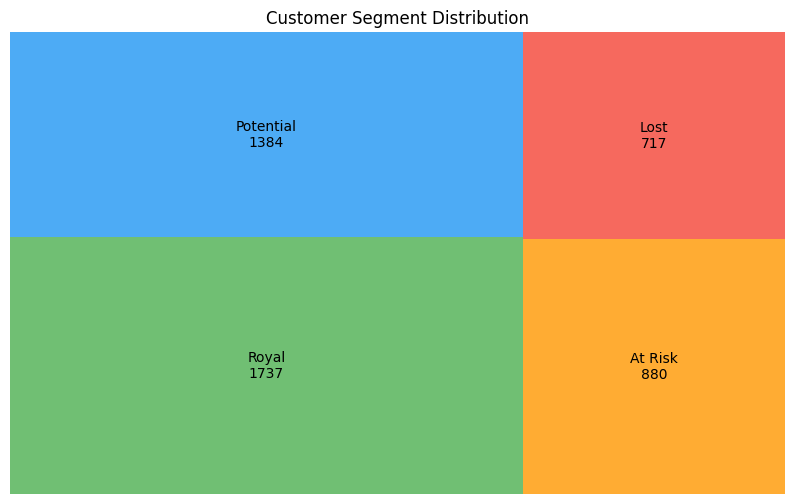

In [419]:
import matplotlib.pyplot as plt
import squarify

# Ambil distribusi segment per customer (unik)
segment_dist = df_sales[['CustomerNo','Segment']].drop_duplicates()

# Hitung jumlah customer per segment
segment_count = segment_dist['Segment'].value_counts()

# Buat label dengan jumlah customer
labels = [f"{seg}\n{count}" for seg, count in zip(segment_count.index, segment_count.values)]

# Ukuran kotak treemap
sizes = segment_count.values

# Plot Treemap
plt.figure(figsize=(10,6))

squarify.plot(
    sizes=sizes,
    label=labels,   # label sekarang sudah ada jumlah customer
    alpha=0.8,
    color=['#4CAF50','#2196F3','#FF9800','#F44336']  # warna berbeda tiap segment
)

plt.title("Customer Segment Distribution")
plt.axis('off')  # matikan axis supaya bersih

plt.show()

### Rata-rata harga produk yang dibeli berdasarkan customer segment

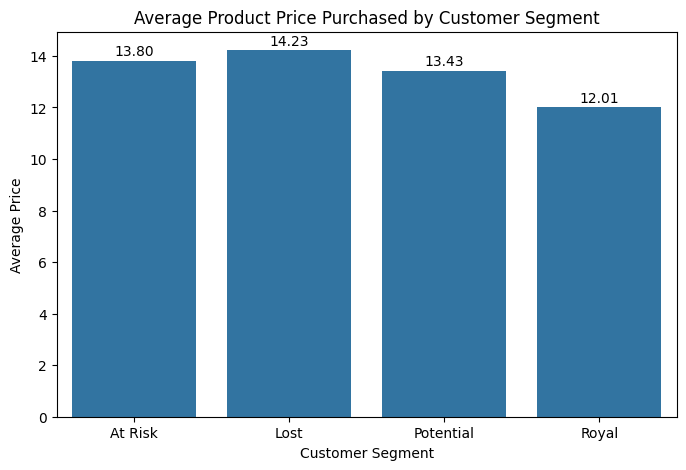

In [420]:
import matplotlib.pyplot as plt
import seaborn as sns

# menghitung rata-rata harga per segment
avg_price_segment = df_sales.groupby('Segment')['Price'].mean().reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(data=avg_price_segment, x='Segment', y='Price')

plt.title("Average Product Price Purchased by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Price")

# menambahkan anotasi pada setiap bar
for i, row in avg_price_segment.iterrows():
    ax.text(
        i,
        row['Price'] + 0.2,
        f"{row['Price']:.2f}",
        ha='center'
    )

plt.show()

Pelanggan pada segmen At Risk membeli produk dengan rata-rata harga 14,06, sedangkan pelanggan pada segmen Lost membeli produk dengan rata-rata harga 13,30.

Perbedaan rata-rata harga tersebut relatif kecil, sehingga harga produk kemungkinan bukan faktor utama yang memengaruhi pelanggan berhenti melakukan pembelian.

### Rata-rata jenis produk yang dibeli berdasarkan customer segment

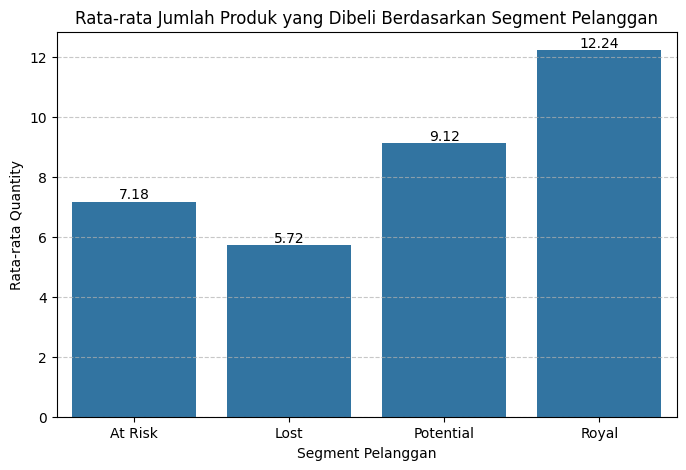

In [421]:
import matplotlib.pyplot as plt
import seaborn as sns

# menghitung rata-rata quantity per segment
avg_quantity_segment = df_sales.groupby('Segment')['Quantity'].mean().reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(data=avg_quantity_segment, x='Segment', y='Quantity')

plt.title("Rata-rata Jumlah Produk yang Dibeli Berdasarkan Segment Pelanggan")
plt.xlabel("Segment Pelanggan")
plt.ylabel("Rata-rata Quantity")

# menambahkan anotasi
for i, row in avg_quantity_segment.iterrows():
    ax.text(
        i,
        row['Quantity'] + 0.1,
        f"{row['Quantity']:.2f}",
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Hal ini menunjukkan bahwa pelanggan yang membeli produk dalam jumlah sedikit biasanya kurang tertarik atau kurang aktif berbelanja

risiko pelanggan menjadi At Risk atau Lost lebih dipengaruhi oleh rendahnya aktivitas pembelian pelanggan, bukan oleh harga produk.

### Tren pembelian top 5 produk

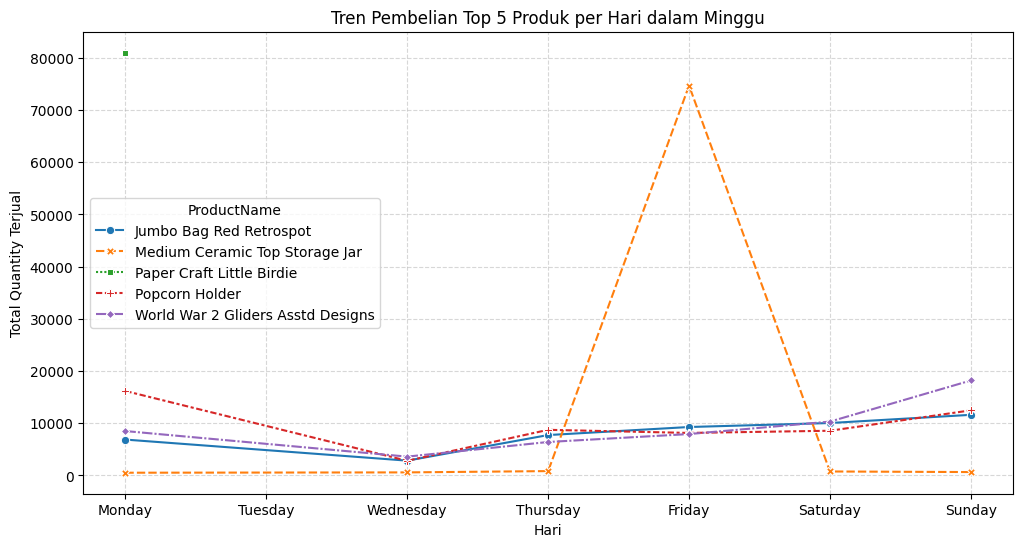

In [422]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Ambil top 5 produk berdasarkan total Quantity
top_products = df_sales.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(5).index

# Filter data hanya untuk top 5 produk
df_top = df_sales[df_sales['ProductName'].isin(top_products)]

# Buat pivot table: index = Day_Name, columns = ProductName, values = sum Quantity
pivot = df_top.pivot_table(index='Day_Name', columns='ProductName', values='Quantity', aggfunc='sum')

# Urutkan hari dalam minggu
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(day_order)

# Plot line chart
plt.figure(figsize=(12,6))
sns.lineplot(data=pivot, markers=True)
plt.title('Tren Pembelian Top 5 Produk per Hari dalam Minggu')
plt.xlabel('Hari')
plt.ylabel('Total Quantity Terjual')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='ProductName')
plt.show()

## Canceled

### Top 10 Produk dengan Jumlah Pelanggan yang Membatalkan Tertinggi

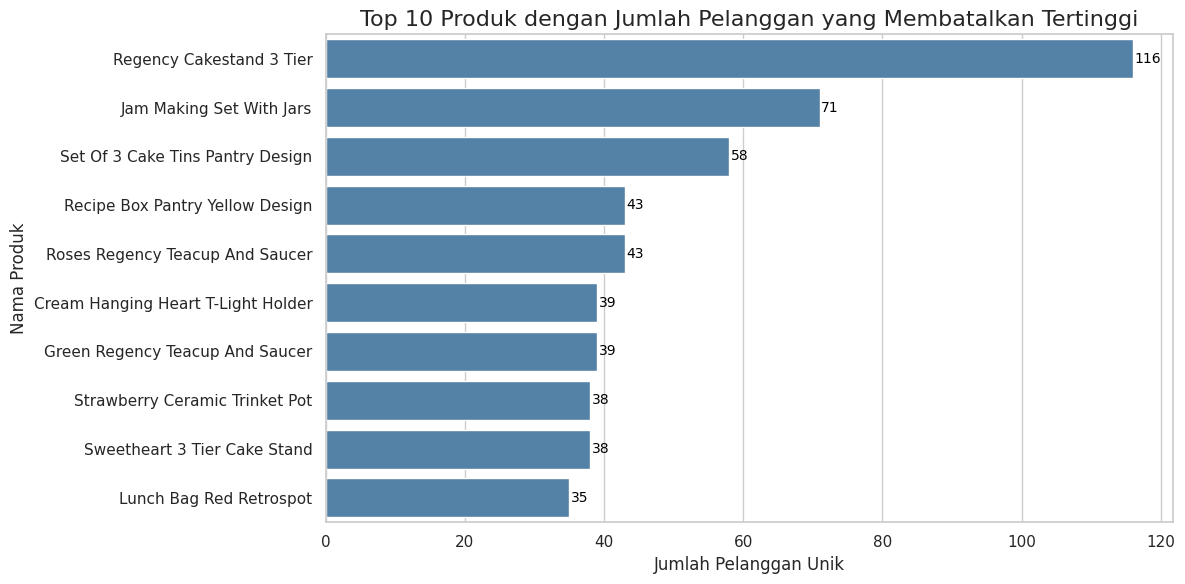

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style seaborn
sns.set(style="whitegrid")

# Hitung jumlah pelanggan unik yang melakukan pembatalan per produk
top_customers_batal = (
    df_sales_batal
    .groupby('ProductName')['CustomerNo']
    .nunique()  # jumlah pelanggan unik
    .sort_values(ascending=False)
    .head(10)
)

# Buat figure
plt.figure(figsize=(12,6))

# Barplot horizontal
ax = sns.barplot(
    x=top_customers_batal.values,
    y=top_customers_batal.index,
    color="steelblue"  # gunakan satu warna agar aman
)

# Judul dan label
plt.title("Top 10 Produk dengan Jumlah Pelanggan yang Membatalkan Tertinggi", fontsize=16)
plt.xlabel("Jumlah Pelanggan Unik", fontsize=12)
plt.ylabel("Nama Produk", fontsize=12)

# Tambahkan anotasi angka di setiap bar
for i, v in enumerate(top_customers_batal.values):
    ax.text(v + 0.2, i, str(v), color='black', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Top produk transaksi batal dengan quantity terbesar

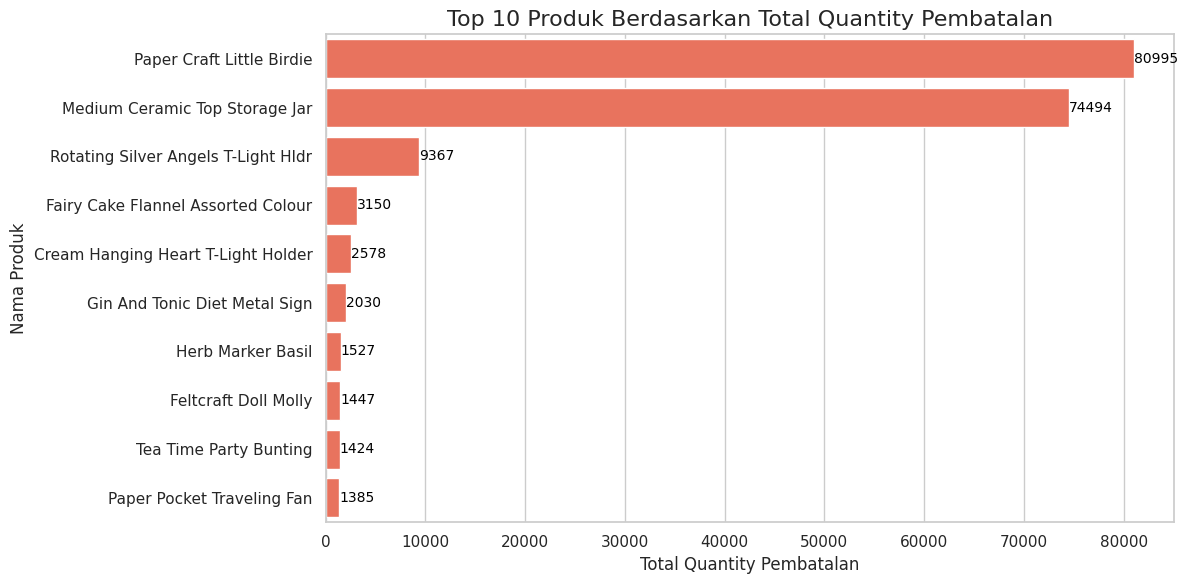

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style seaborn
sns.set(style="whitegrid")

# Pilih 10 produk teratas
top10_cancel_qty = top_cancel_product.head(10)

# Buat figure
plt.figure(figsize=(12,6))

# Barplot horizontal
ax = sns.barplot(
    x='Quantity',
    y='ProductName',
    data=top10_cancel_qty,
    color='tomato'
)

# Judul dan label
plt.title("Top 10 Produk Berdasarkan Total Quantity Pembatalan", fontsize=16)
plt.xlabel("Total Quantity Pembatalan", fontsize=12)
plt.ylabel("Nama Produk", fontsize=12)

# Tambahkan anotasi angka di setiap bar
for i, v in enumerate(top10_cancel_qty['Quantity']):
    ax.text(v + 0.2, i, str(v), color='black', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Top 10 negara dengan jumlah transaksi tertinggi

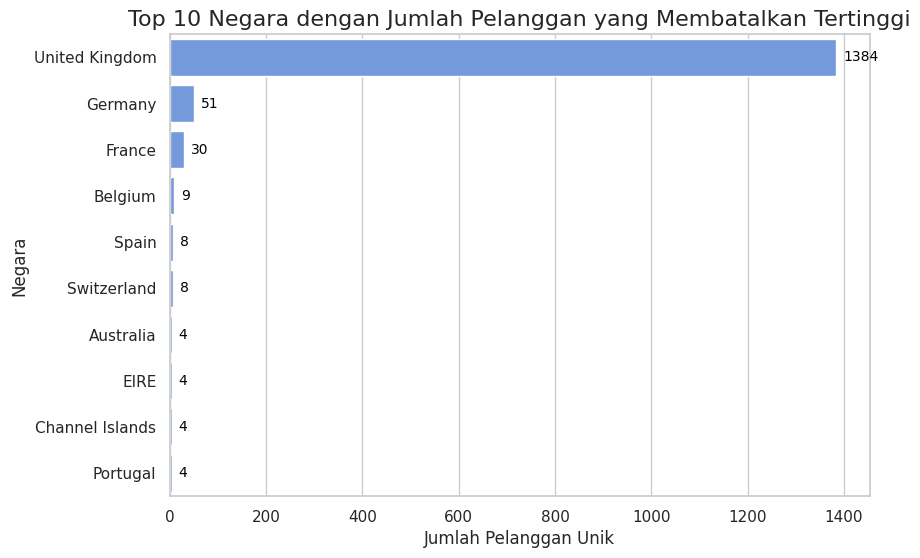

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah pelanggan unik yang melakukan pembatalan per negara
customers_batal_per_negara = (
    df_sales_batal
    .groupby('Country')['CustomerNo']
    .nunique()  # jumlah pelanggan unik
    .sort_values(ascending=False)
)

# Ambil top 10
top10_negara_batal = customers_batal_per_negara.head(10).reset_index()
top10_negara_batal.rename(columns={'CustomerNo':'Jumlah_Pelanggan'}, inplace=True)

# Set style
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(10,6))

# Barplot horizontal
sns.barplot(
    x='Jumlah_Pelanggan',
    y='Country',
    data=top10_negara_batal,
    color='cornflowerblue',
    ax=ax
)

# Judul dan label
ax.set_title("Top 10 Negara dengan Jumlah Pelanggan yang Membatalkan Tertinggi", fontsize=16)
ax.set_xlabel("Jumlah Pelanggan Unik", fontsize=12)
ax.set_ylabel("Negara", fontsize=12)

# Tambahkan anotasi angka di ujung bar
for i, v in enumerate(top10_negara_batal['Jumlah_Pelanggan']):
    ax.text(v + max(top10_negara_batal['Jumlah_Pelanggan'])*0.01, i, str(v), color='black', va='center', fontsize=10)

# Atur margin manual
plt.subplots_adjust(left=0.25, right=0.95)
plt.show()

### Tren jumlah transaksi pembatalan

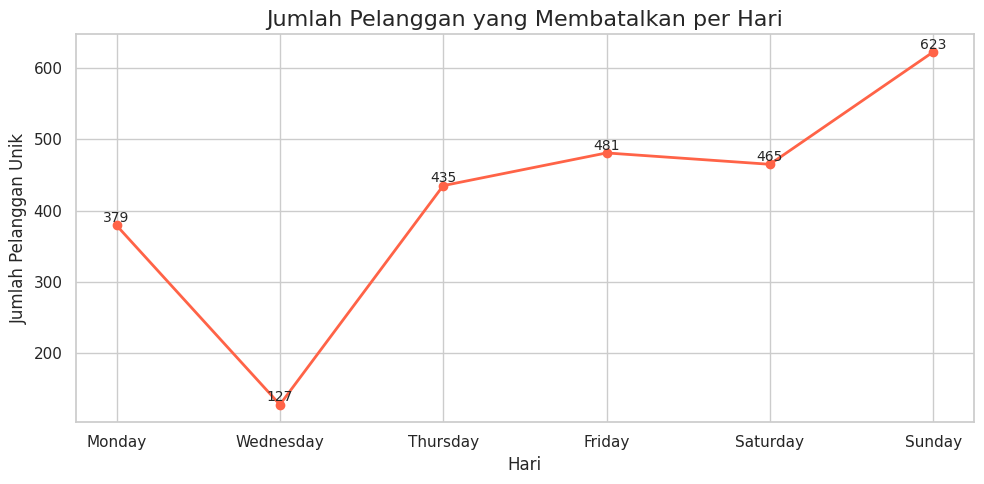

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Hitung jumlah pelanggan unik yang membatalkan per hari
cancel_per_day = (
    df_sales_batal
    .groupby('Day_Name')['CustomerNo']
    .nunique()  # jumlah pelanggan unik
)

# Reset index supaya bisa plot
cancel_per_day_df = cancel_per_day.reset_index()

# Urutkan hari Senin → Minggu
hari_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cancel_per_day_df['Day_Name'] = pd.Categorical(cancel_per_day_df['Day_Name'], categories=hari_order, ordered=True)
cancel_per_day_df = cancel_per_day_df.sort_values('Day_Name')

# Set style
sns.set(style="whitegrid")

# Plot line
plt.figure(figsize=(10,5))
plt.plot(cancel_per_day_df['Day_Name'], cancel_per_day_df['CustomerNo'], marker='o', color='tomato', linewidth=2)

# Judul dan label
plt.title("Jumlah Pelanggan yang Membatalkan per Hari", fontsize=16)
plt.xlabel("Hari", fontsize=12)
plt.ylabel("Jumlah Pelanggan Unik", fontsize=12)

# Tambahkan anotasi angka di tiap titik
for x, y in zip(cancel_per_day_df['Day_Name'], cancel_per_day_df['CustomerNo']):
    plt.text(x, y + 0.5, str(y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()